# Bondview Duration — 2022 10Y Trend Visual Check

This notebook visually inspects the **2022 10Y Treasury** episode that triggered the required **Task 2B — Trend State-Classification Validation**.

It intentionally **reuses committed validation outputs** rather than recomputing the model:

- `validation/261002_duration/task2_trend/comparison.csv`
- `validation/261002_duration/task1_core/results.csv`

The main question is narrow:

> Does the provisional 3M Trend Value `M5(t) - M5(t-63)` cross the fixed ±25 bp State boundary in a way that is economically meaningful and stable enough for Duration Core Rule Cases?

The notebook does **not** change thresholds, smoothing, Trend construction, Recent Move, or Core mapping.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "validation/261002_duration/task2_trend/comparison.csv").exists():
            return p
    raise FileNotFoundError(
        "Could not find bondview-v2 repository root. "
        "Run this notebook from inside the repository, or set REPO_ROOT manually."
    )

REPO_ROOT = find_repo_root()
TASK2 = REPO_ROOT / "validation/261002_duration/task2_trend/comparison.csv"
TASK1 = REPO_ROOT / "validation/261002_duration/task1_core/results.csv"

REPO_ROOT, TASK2, TASK1


(PosixPath('/home/lbk/works/bondview-v2'),
 PosixPath('/home/lbk/works/bondview-v2/validation/261002_duration/task2_trend/comparison.csv'),
 PosixPath('/home/lbk/works/bondview-v2/validation/261002_duration/task1_core/results.csv'))

## 1. Load the committed Task-2 comparison and Task-1 yield snapshot

Task 2's preferred Trend construction is:

```text
B Trend = M5(t) - M5(t-63)
```

The Task-2 baseline is:

```text
A Trend = M5(t) - M5(t-126)
```

Recent Move remains:

```text
M5(t) - M5(t-21)
```

Task 2 held the State thresholds fixed at:

```text
Trend       ±25 bp
Recent Move ±10 bp
```


In [2]:
task2 = pd.read_csv(TASK2, parse_dates=["as_of"])
task1 = pd.read_csv(TASK1, parse_dates=["as_of"])

required_task2 = {
    "as_of", "representative_tenor", "recent_move_bp", "recent_move_state",
    "A_trend_bp", "A_trend_state", "A_rule_case", "A_core_candidates",
    "B_trend_bp", "B_trend_state", "B_rule_case", "B_core_candidates",
}
missing = required_task2 - set(task2.columns)
if missing:
    raise ValueError(f"Task-2 comparison.csv is missing expected columns: {sorted(missing)}")

required_task1 = {"as_of", "representative_tenor", "yield_pct"}
missing = required_task1 - set(task1.columns)
if missing:
    raise ValueError(f"Task-1 results.csv is missing expected columns: {sorted(missing)}")

print("Task-2 rows:", len(task2))
print("Task-1 rows:", len(task1))


Task-2 rows: 38246
Task-1 rows: 50676


In [3]:
start = pd.Timestamp("2022-01-01")
end   = pd.Timestamp("2022-10-31")

t2_10y = (
    task2.loc[
        (task2["representative_tenor"] == "10Y")
        & task2["as_of"].between(start, end)
    ]
    .sort_values("as_of")
    .copy()
)

t1_10y = (
    task1.loc[
        (task1["representative_tenor"] == "10Y")
        & task1["as_of"].between(start, end)
    ]
    .sort_values("as_of")
    .copy()
)

# Keep only actual source observations for the yield-level chart.
if "availability" in t1_10y.columns:
    t1_10y = t1_10y[t1_10y["availability"].isin(
        ["available", "insufficient_130_observation_history"]
    )].copy()

print("2022 Task-2 10Y observations:", len(t2_10y))
print("2022 Task-1 10Y observations:", len(t1_10y))


2022 Task-2 10Y observations: 208
2022 Task-1 10Y observations: 208


## 2. Underlying 10Y Treasury yield

This is the raw economic path behind the derived Trend and Recent Move values.

The chart is useful because a State label should remain interpretable in relation to the actual yield path, not only to the classification formula.


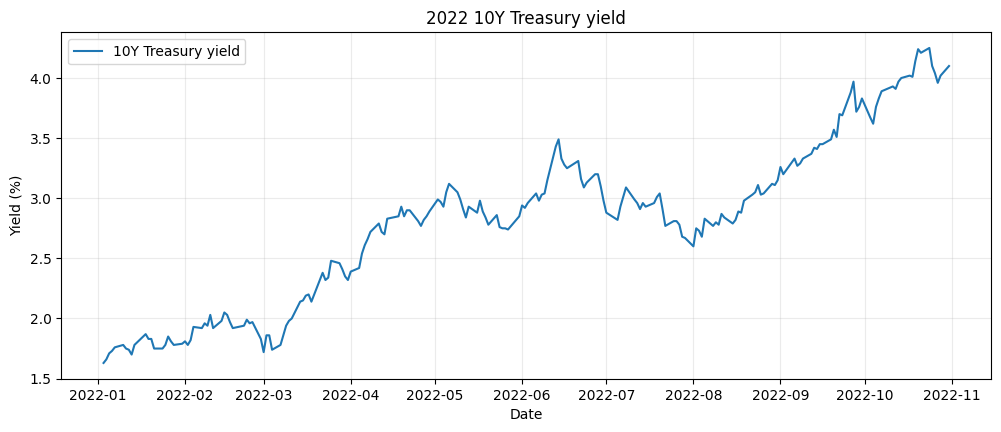

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(t1_10y["as_of"], t1_10y["yield_pct"], label="10Y Treasury yield")
ax.set_title("2022 10Y Treasury yield")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 3. Task-2 Trend comparison: 6M baseline vs preferred 3M Trend

The important comparison is:

```text
A = M5(t) - M5(t-126)   # 6M baseline
B = M5(t) - M5(t-63)    # 3M preferred
```

The horizontal ±25 bp lines are the **unchanged Task-2 classification boundaries**.

This plot should make two Task-2 findings visible:

1. the 3M Trend turns much faster than the old 6M Trend;
2. around the 2022 midsummer relief, the 3M Trend can cross a boundary only marginally and briefly.


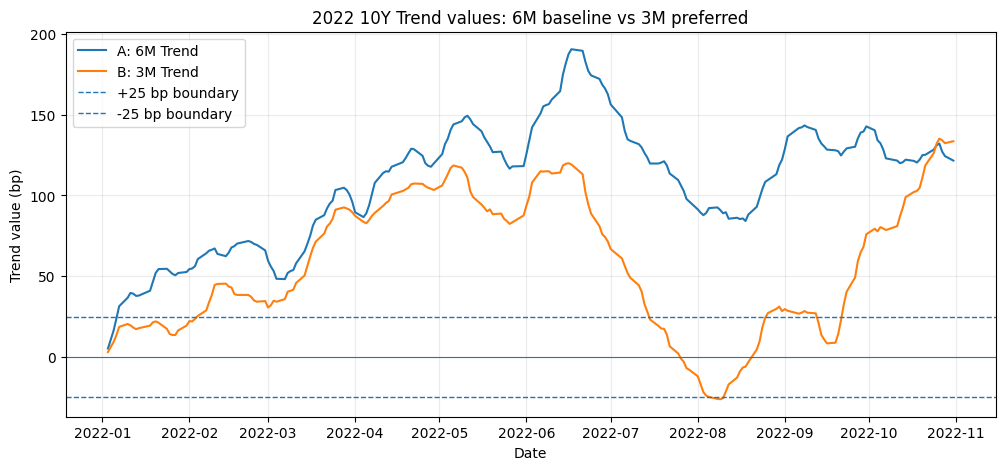

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t2_10y["as_of"], t2_10y["A_trend_bp"], label="A: 6M Trend")
ax.plot(t2_10y["as_of"], t2_10y["B_trend_bp"], label="B: 3M Trend")
ax.axhline(25, linestyle="--", linewidth=1, label="+25 bp boundary")
ax.axhline(-25, linestyle="--", linewidth=1, label="-25 bp boundary")
ax.axhline(0, linewidth=0.8)
ax.set_title("2022 10Y Trend values: 6M baseline vs 3M preferred")
ax.set_xlabel("Date")
ax.set_ylabel("Trend value (bp)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 4. Zoom on the Task-2 boundary issue

Task 2 identified the 2022 10Y episode as a central reason that State Classification needs a separate review.

The report found that the 3M Trend:

- became `Stable` in mid-July;
- briefly crossed below `-25 bp` around **August 8–10**;
- returned to `Stable`;
- later became `Rising`.

The key question is whether a few observations only slightly below `-25 bp` should carry the full semantic meaning of a `Falling` broader Trend.


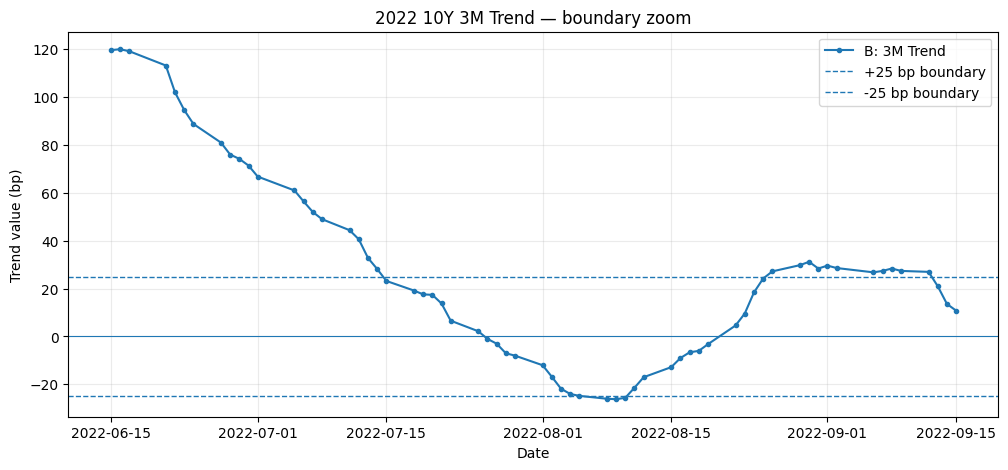

In [6]:
zoom_start = pd.Timestamp("2022-06-15")
zoom_end   = pd.Timestamp("2022-09-15")
zoom = t2_10y[t2_10y["as_of"].between(zoom_start, zoom_end)].copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(zoom["as_of"], zoom["B_trend_bp"], marker=".", label="B: 3M Trend")
ax.axhline(25, linestyle="--", linewidth=1, label="+25 bp boundary")
ax.axhline(-25, linestyle="--", linewidth=1, label="-25 bp boundary")
ax.axhline(0, linewidth=0.8)
ax.set_title("2022 10Y 3M Trend — boundary zoom")
ax.set_xlabel("Date")
ax.set_ylabel("Trend value (bp)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 5. Recent Move alongside the preferred Trend

Recent Move is not under review in Task 2B, but it is useful context because the Core Rule Case is based on:

```text
Trend State × Recent Move State
```

This chart shows whether the shorter-horizon move is reinforcing or opposing the broader Trend.


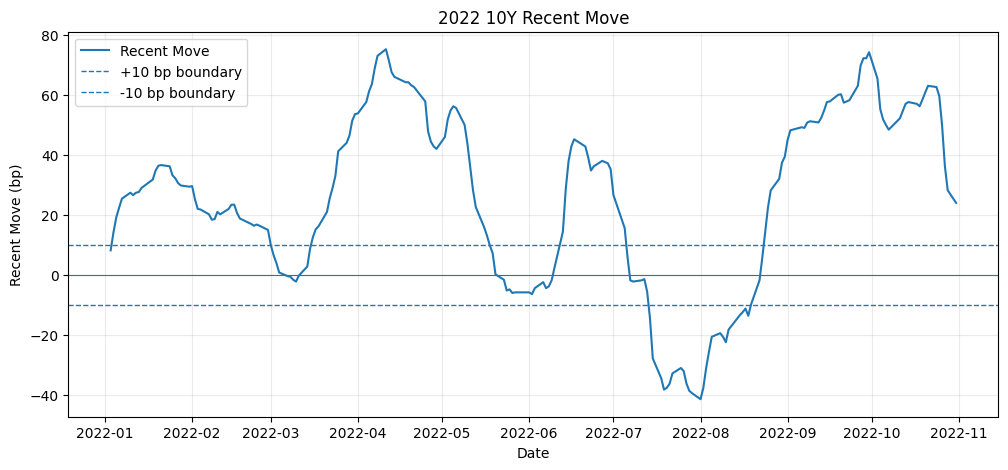

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t2_10y["as_of"], t2_10y["recent_move_bp"], label="Recent Move")
ax.axhline(10, linestyle="--", linewidth=1, label="+10 bp boundary")
ax.axhline(-10, linestyle="--", linewidth=1, label="-10 bp boundary")
ax.axhline(0, linewidth=0.8)
ax.set_title("2022 10Y Recent Move")
ax.set_xlabel("Date")
ax.set_ylabel("Recent Move (bp)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 6. State path

For visualization only, the categorical States are encoded as:

```text
Falling = -1
Stable  =  0
Rising  = +1
```

These numbers are **not scores** and must not be treated as cardinal quantities. They are used here only to draw categorical State paths.


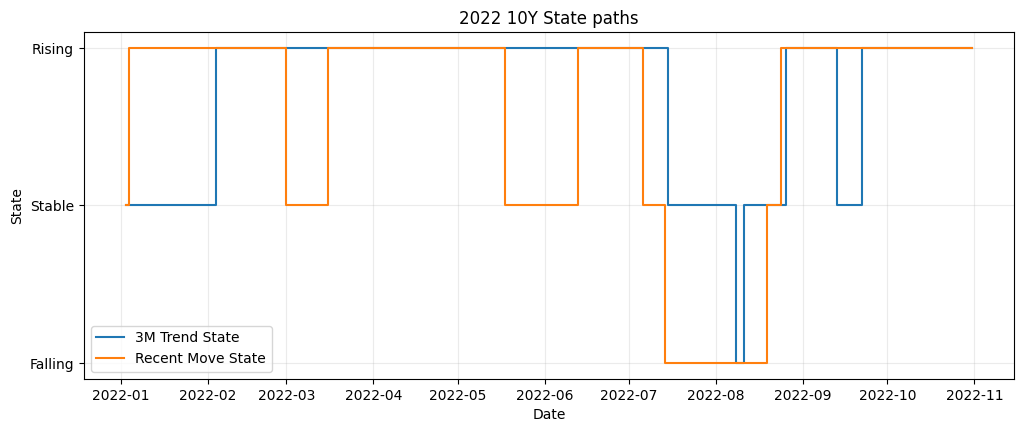

In [8]:
state_code = {"Falling": -1, "Stable": 0, "Rising": 1}

state_view = t2_10y[["as_of", "B_trend_state", "recent_move_state"]].copy()
state_view["Trend"] = state_view["B_trend_state"].map(state_code)
state_view["Recent"] = state_view["recent_move_state"].map(state_code)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.step(state_view["as_of"], state_view["Trend"], where="post", label="3M Trend State")
ax.step(state_view["as_of"], state_view["Recent"], where="post", label="Recent Move State")
ax.set_yticks([-1, 0, 1], ["Falling", "Stable", "Rising"])
ax.set_title("2022 10Y State paths")
ax.set_xlabel("Date")
ax.set_ylabel("State")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 7. Exact boundary-adjacent observations

The table below focuses on observations close to the ±25 bp Trend boundary.

A narrow crossing can matter greatly because it changes the categorical Trend State and therefore the `Trend × Recent Move` Rule Case.


In [9]:
boundary_distance = (t2_10y["B_trend_bp"].abs() - 25).abs()

boundary_rows = t2_10y.loc[
    (boundary_distance <= 5)
    & t2_10y["as_of"].between(pd.Timestamp("2022-06-01"), pd.Timestamp("2022-09-30")),
    [
        "as_of",
        "B_trend_bp", "B_trend_state",
        "recent_move_bp", "recent_move_state",
        "B_rule_case", "B_core_candidates",
        "A_trend_bp", "A_trend_state", "A_rule_case", "A_core_candidates",
    ],
].copy()

boundary_rows


,as_of,B_trend_bp,B_trend_state,recent_move_bp,recent_move_state,B_rule_case,B_core_candidates,A_trend_bp,A_trend_state,A_rule_case,A_core_candidates
26086,2022-07-14,28.2,Rising,-14.4,Falling,Rising × Falling,[-1],123.6,Rising,Rising × Falling,[-1]
26087,2022-07-15,23.2,Stable,-27.8,Falling,Stable × Falling,[1],119.8,Rising,Rising × Falling,[-1]
26100,2022-08-03,-21.8,Stable,-31.0,Falling,Stable × Falling,[1],87.8,Rising,Rising × Falling,[-1]
26101,2022-08-04,-24.0,Stable,-25.6,Falling,Stable × Falling,[1],89.2,Rising,Rising × Falling,[-1]
26102,2022-08-05,-24.8,Stable,-20.6,Falling,Stable × Falling,[1],92.2,Rising,Rising × Falling,[-1]
26103,2022-08-08,-26.0,Falling,-19.4,Falling,Falling × Falling,[2],92.6,Rising,Rising × Falling,[-1]
26104,2022-08-09,-26.2,Falling,-20.6,Falling,Falling × Falling,[2],91.0,Rising,Rising × Falling,[-1]
26105,2022-08-10,-25.6,Falling,-22.4,Falling,Falling × Falling,[2],89.0,Rising,Rising × Falling,[-1]
26106,2022-08-11,-21.4,Stable,-18.2,Falling,Stable × Falling,[1],89.6,Rising,Rising × Falling,[-1]
26116,2022-08-25,24.2,Stable,22.4,Rising,Stable × Rising,[-1],108.4,Rising,Rising × Rising,[-2]


## 8. Detect every 3M Trend State transition in the 2022 window

This is useful for seeing whether the classification is persistent or repeatedly returns across a boundary.


In [10]:
transition_mask = t2_10y["B_trend_state"].ne(t2_10y["B_trend_state"].shift())

trend_transitions = t2_10y.loc[
    transition_mask,
    [
        "as_of",
        "B_trend_bp", "B_trend_state",
        "recent_move_bp", "recent_move_state",
        "B_rule_case", "B_core_candidates",
    ],
].copy()

trend_transitions


,as_of,B_trend_bp,B_trend_state,recent_move_bp,recent_move_state,B_rule_case,B_core_candidates
25954,2022-01-03,3.0,Stable,8.2,Stable,Stable × Stable,[0]
25977,2022-02-04,25.4,Rising,21.8,Rising,Rising × Rising,[-2]
26087,2022-07-15,23.2,Stable,-27.8,Falling,Stable × Falling,[1]
26103,2022-08-08,-26.0,Falling,-19.4,Falling,Falling × Falling,[2]
26106,2022-08-11,-21.4,Stable,-18.2,Falling,Stable × Falling,[1]
26117,2022-08-26,27.2,Rising,28.2,Rising,Rising × Rising,[-2]
26128,2022-09-13,21.0,Stable,52.4,Rising,Stable × Rising,[-1]
26135,2022-09-22,32.6,Rising,57.8,Rising,Rising × Rising,[-2]


## 9. Focus on the August 2022 crossing

Task 2 reported a brief 10Y `Falling` classification at roughly `-26 bp`.

This cell prints a tight window around that event so the magnitude, State, Recent Move, Rule Case, and Core candidates can be inspected together.


In [11]:
august = t2_10y.loc[
    t2_10y["as_of"].between(pd.Timestamp("2022-08-01"), pd.Timestamp("2022-08-19")),
    [
        "as_of",
        "B_trend_bp", "B_trend_state",
        "recent_move_bp", "recent_move_state",
        "B_rule_case", "B_core_candidates",
        "A_trend_bp", "A_trend_state",
    ],
].copy()

august


,as_of,B_trend_bp,B_trend_state,recent_move_bp,recent_move_state,B_rule_case,B_core_candidates,A_trend_bp,A_trend_state
26098,2022-08-01,-12.0,Stable,-41.4,Falling,Stable × Falling,[1],91.4,Rising
26099,2022-08-02,-16.8,Stable,-37.6,Falling,Stable × Falling,[1],89.4,Rising
26100,2022-08-03,-21.8,Stable,-31.0,Falling,Stable × Falling,[1],87.8,Rising
26101,2022-08-04,-24.0,Stable,-25.6,Falling,Stable × Falling,[1],89.2,Rising
26102,2022-08-05,-24.8,Stable,-20.6,Falling,Stable × Falling,[1],92.2,Rising
26103,2022-08-08,-26.0,Falling,-19.4,Falling,Falling × Falling,[2],92.6,Rising
26104,2022-08-09,-26.2,Falling,-20.6,Falling,Falling × Falling,[2],91.0,Rising
26105,2022-08-10,-25.6,Falling,-22.4,Falling,Falling × Falling,[2],89.0,Rising
26106,2022-08-11,-21.4,Stable,-18.2,Falling,Stable × Falling,[1],89.6,Rising
26107,2022-08-12,-17.0,Stable,-17.0,Falling,Stable × Falling,[1],85.6,Rising


## 10. Diagnostic questions for Task 2B

Use the charts and tables above to answer these questions before selecting classification alternatives:

1. Does the continuous 3M Trend Value itself look economically plausible through the 2022 relief/reversal?
2. Is the brief `Falling` State around August 8–10 a meaningful broader-condition change, or mainly a threshold-boundary artifact?
3. How large is the change in economic interpretation when the Trend moves from `Stable` to `Falling` and back?
4. Does the State path become too sensitive near ±25 bp even though the underlying continuous Value changes only slightly?
5. Would any stabilization rule risk delaying genuine reversals such as the 1980 case?
6. Is the problem specifically **State Classification**, or does this visual inspection reveal a deeper problem with the selected 3M Trend Value?

The notebook deliberately does not answer these by optimizing a parameter. Its purpose is to make the Task-2B design decision visually inspectable.
